# Topics:

- Handling missing values

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)

2.3.3


## handle missing values, duplicates

In [58]:
# data = {
#     'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Helen', 'Helen', 'Jerry'],
#     'Age': [25, 30, 35, 40, 22, 28, 32, 26, 26, 26, 23],
#     'City': ['Chicago', 'Los Angeles', 'Chicago', 'Houston', 'Houston', np.nan, 'San Antonio', 'San Diego', 'San Diego', 'San Diego', 'Phoenix'],
#     'Experience': [2, 5, 7, 10, 1, 3, 6, 2, 2, 2, 6],
#     'Experience2': [2, 5, 7, 10, 1, 3, 6, 2, 2, 2, 6],
#     'Salary': [70000.0, 80000.0, np.nan, 90000.0, 48000.0, 72000.0, 85000.0, 62000.0, 62000.0, 62000.0, 78000.0]
# }

# df = pd.DataFrame(data)
# print(df)
# df.to_csv('missing_data.csv', index=False)

df = pd.read_csv('missing_data.csv')

In [59]:
print(df)

       Name   Age         City  Experience  dist_from_office   Salary
0     Alice  25.0      Chicago         2.0               6.0  70000.0
1       Bob  30.0  Los Angeles         5.0               NaN  80000.0
2   Charlie  35.0      Chicago         7.0               NaN      NaN
3     David  40.0      Houston        10.0               NaN  90000.0
4       Eva  22.0      Houston         1.0               NaN  48000.0
5     Frank  28.0          NaN         3.0               3.0  72000.0
6     Grace  32.0  San Antonio         6.0               6.0  85000.0
7     Helen  26.0    San Diego         2.0               NaN  62000.0
8     Helen  26.0    San Diego         2.0               NaN  62000.0
9     Helen  26.0    San Diego         2.0               2.0  62000.0
10      NaN   NaN          NaN         NaN               NaN      NaN
11    Jerry  23.0      Phoenix         6.0               NaN  78000.0


In [60]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              11 non-null     object 
 1   Age               11 non-null     float64
 2   City              10 non-null     object 
 3   Experience        11 non-null     float64
 4   dist_from_office  4 non-null      float64
 5   Salary            10 non-null     float64
dtypes: float64(4), object(2)
memory usage: 708.0+ bytes
None


#### observation
- Total entries are 12; total columns are 6
- Give data type for each column
- city has 10 non-null values, so it has 2 missing value
- Salary has 10 non-null values, so it has 2 missing value


# Display missing values for each column

In [61]:
missing_values = df.isnull().sum()

print("\nMissing Values:\n", missing_values )


Missing Values:
 Name                1
Age                 1
City                2
Experience          1
dist_from_office    8
Salary              2
dtype: int64


#### observation
- Name has 1 missing value
- city has 2 missing value
- Salary has 2 missing value


In [62]:
# I want to see if a certain cell has missing value or not
print(df)
print("+++++++++++++++++++")
print(df.isnull())

       Name   Age         City  Experience  dist_from_office   Salary
0     Alice  25.0      Chicago         2.0               6.0  70000.0
1       Bob  30.0  Los Angeles         5.0               NaN  80000.0
2   Charlie  35.0      Chicago         7.0               NaN      NaN
3     David  40.0      Houston        10.0               NaN  90000.0
4       Eva  22.0      Houston         1.0               NaN  48000.0
5     Frank  28.0          NaN         3.0               3.0  72000.0
6     Grace  32.0  San Antonio         6.0               6.0  85000.0
7     Helen  26.0    San Diego         2.0               NaN  62000.0
8     Helen  26.0    San Diego         2.0               NaN  62000.0
9     Helen  26.0    San Diego         2.0               2.0  62000.0
10      NaN   NaN          NaN         NaN               NaN      NaN
11    Jerry  23.0      Phoenix         6.0               NaN  78000.0
+++++++++++++++++++
     Name    Age   City  Experience  dist_from_office  Salary
0   Fals

In [63]:
# Lets determine percentage of missing values per column:

missing_per_column = df.isnull().mean() * 100
print(missing_per_column)

Name                 8.333333
Age                  8.333333
City                16.666667
Experience           8.333333
dist_from_office    66.666667
Salary              16.666667
dtype: float64


In [64]:
# Lets determine percentage of missing values in the entire dataset:

total_cells = df.size
total_missing = df.isnull().sum().sum()
missing_percentage = (total_missing / total_cells) * 100
print(f"Total cells with missing values: {total_missing}")
print(f"Percentage of missing data in dataset: {missing_percentage:.2f}%")

Total cells with missing values: 15
Percentage of missing data in dataset: 20.83%


# SOLUTIONS

## Drop rows or columns

In [65]:
# Since dist_from_office is missing > 60% of data, so we drop this
print(df)
print("+++++++++++++")
df_clean = df.drop(['dist_from_office'], axis=1) # drop column dist_from_office
print(df_clean)

       Name   Age         City  Experience  dist_from_office   Salary
0     Alice  25.0      Chicago         2.0               6.0  70000.0
1       Bob  30.0  Los Angeles         5.0               NaN  80000.0
2   Charlie  35.0      Chicago         7.0               NaN      NaN
3     David  40.0      Houston        10.0               NaN  90000.0
4       Eva  22.0      Houston         1.0               NaN  48000.0
5     Frank  28.0          NaN         3.0               3.0  72000.0
6     Grace  32.0  San Antonio         6.0               6.0  85000.0
7     Helen  26.0    San Diego         2.0               NaN  62000.0
8     Helen  26.0    San Diego         2.0               NaN  62000.0
9     Helen  26.0    San Diego         2.0               2.0  62000.0
10      NaN   NaN          NaN         NaN               NaN      NaN
11    Jerry  23.0      Phoenix         6.0               NaN  78000.0
+++++++++++++
       Name   Age         City  Experience   Salary
0     Alice  25.0      C

In [66]:
# Drop rows that has any column with missing value

print(df)
print("+++++++++++++")
df_clean = df.dropna(axis=0) # drop all rows with missing values
print(df_clean)

       Name   Age         City  Experience  dist_from_office   Salary
0     Alice  25.0      Chicago         2.0               6.0  70000.0
1       Bob  30.0  Los Angeles         5.0               NaN  80000.0
2   Charlie  35.0      Chicago         7.0               NaN      NaN
3     David  40.0      Houston        10.0               NaN  90000.0
4       Eva  22.0      Houston         1.0               NaN  48000.0
5     Frank  28.0          NaN         3.0               3.0  72000.0
6     Grace  32.0  San Antonio         6.0               6.0  85000.0
7     Helen  26.0    San Diego         2.0               NaN  62000.0
8     Helen  26.0    San Diego         2.0               NaN  62000.0
9     Helen  26.0    San Diego         2.0               2.0  62000.0
10      NaN   NaN          NaN         NaN               NaN      NaN
11    Jerry  23.0      Phoenix         6.0               NaN  78000.0
+++++++++++++
    Name   Age         City  Experience  dist_from_office   Salary
0  Alice 

In [67]:
# Drop rows with 'ALL' missing values

print(df)
print("+++++++++++++")
df_clean = df.dropna(how='all') 
print(df_clean)

       Name   Age         City  Experience  dist_from_office   Salary
0     Alice  25.0      Chicago         2.0               6.0  70000.0
1       Bob  30.0  Los Angeles         5.0               NaN  80000.0
2   Charlie  35.0      Chicago         7.0               NaN      NaN
3     David  40.0      Houston        10.0               NaN  90000.0
4       Eva  22.0      Houston         1.0               NaN  48000.0
5     Frank  28.0          NaN         3.0               3.0  72000.0
6     Grace  32.0  San Antonio         6.0               6.0  85000.0
7     Helen  26.0    San Diego         2.0               NaN  62000.0
8     Helen  26.0    San Diego         2.0               NaN  62000.0
9     Helen  26.0    San Diego         2.0               2.0  62000.0
10      NaN   NaN          NaN         NaN               NaN      NaN
11    Jerry  23.0      Phoenix         6.0               NaN  78000.0
+++++++++++++
       Name   Age         City  Experience  dist_from_office   Salary
0     

In [ ]:
# Drop rows where Salary has missing values

print(df)
print("+++++++++++++")
df_clean = df.dropna(subset=['Salary']) 
print(df_clean)

## Manually add value if you know 

In [ ]:
df_clean = df.copy()
df_clean['Salary'] = df['Salary'].fillna(0) # manually added 0
df_clean['City'] = df['City'].fillna('UNKNOWN')
print("\nDataFrame after filling missing values:\n", df_clean)

## Mean, Median, or Mode Imputation (Univariate Imputation)

## A) Mean imputation

In [ ]:
#SKIP (First lets generate data) Set random seed for reproducibility
np.random.seed(42)

# # Step 1: Create a DataFrame with 60 patients and normally distributed blood pressure readings
# data = {
#     'Patient_ID': [f'P{i+1:03d}' for i in range(60)],
#     'BP': np.random.normal(loc=120, scale=10, size=60)  # mean=120, std=10
# }

# df = pd.DataFrame(data)

# # Step 2: Randomly insert missing values (about 20% of them)
# missing_indices = np.random.choice(df.index, size=12, replace=False)
# df.loc[missing_indices, 'BP'] = np.nan
# df.to_csv('missing_patient_BP.csv', index=False)
###################################################################


In [ ]:
# 1) read the data and print

df = pd.read_csv('missing_patient_BP.csv')
print(df)

In [ ]:
# 2) Lets plot the blood pressure and verify that it hass normal distribution
x = df['BP']

sns.histplot(x,
             kde=True,
             # bins=15,
             # color='blue',
             # label='Original (with NaN)'
)
plt.show()

# KDE Plot 
sns.kdeplot(x,
            color='blue',
            label='Original (with NaN)'
)

plt.show()

### obseravtion:
- the Blood Pressure has normal distribution curve. So we can fill the mising value with **mean value.**

In [ ]:
# 3) 
mean_bp = df['BP'].mean()
df['BP_Imputed'] = df['BP'].fillna(mean_bp)

# Compare before and after
print("\nMean Blood Pressure before imputation (ignoring NaN):", round(mean_bp, 2))
print("\nData after Mean Imputation:\n", df)

In [ ]:
# 4) Visualize the difference
x          = df['Patient_ID']
bp         = df['BP']
plt.figure(figsize=(12, 6))
plt.plot(x, bp,          label='Original', marker='o', linestyle='-', color='blue')   # with missing

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [ ]:
# 4) Visualize the difference
x          = df['Patient_ID']
bp         = df['BP']
bp_imputed = df['BP_Imputed']


plt.figure(figsize=(12, 6))
plt.plot(x, bp,          label='Original', marker='o', linestyle='-', color='blue')   # with missing
plt.plot(x, bp_imputed , label='Imputed',  marker='*', linestyle='--', color='green') # without missing

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

#### observation:
- the missing values for patient p006, p008,p012, etc are all imputed with same number, mean = 118

In [ ]:
# 5)
# Create copies to compare
original = df['BP']
imputed = df['BP_Imputed']

# Set up the plot
plt.figure(figsize=(14, 6))

# Histogram comparison
plt.subplot(1, 2, 1)
sns.histplot(original, kde=True, bins=15, color='blue', label='Original (with NaN)')
sns.histplot(imputed, kde=True, bins=15, color='green', label='Imputed (mean)', alpha=0.5)
plt.title("Histogram: Original vs Imputed")
plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Frequency")
plt.legend()

# KDE Plot comparison
plt.subplot(1, 2, 2)
sns.kdeplot(original, color='blue', label='Original (with NaN)')
sns.kdeplot(imputed, color='green', label='Imputed (mean)')
plt.title("KDE Plot: Original vs Imputed")
plt.xlabel("Blood Pressure (mmHg)")
plt.legend()

plt.tight_layout()
plt.show()

# Descriptive statistics
print("\n Descriptive Statistics:")
print("Original (ignoring NaN):")
print(original.describe())
print("\nAfter Imputation (mean):")
print(imputed.describe())


#### observation
what are you looking for ?

- The KDE plots should look very similar since mean imputation doesn’t distort the shape much: **Thats true here**
- The histogram will show some stacked bars at the imputed mean value: **Thats true here as you can see tall bar at 118**
- The mean will be the same, but the std might slightly reduce due to flattening of the variance: **The mean is same in both, and std_dev went down from 9.2 to 8.2**

## B) Median imputation

In [ ]:
# (SKIP)
np.random.seed(42) # Set seed for reproducibility

# # Step 1: Generate skewed data (using exponential distribution)
# visits = np.random.exponential(scale=3, size=60).round()

# # Step 2: Introduce missing values in about 15% of records
# mask = np.random.choice([True, False], size=60, p=[0.15, 0.85])
# visits[mask] = np.nan

# # Step 3: Create DataFrame
# # This is the number of monthly doctor visits by patients in a clinic. Some patients didn’t 
# # report their number of visits. The data is skewed because a few patients visit
# # the doctor very frequently (outliers).
# df = pd.DataFrame({'Monthly_Doctor_Visits': visits})
# df.to_csv('missing_monthly_dr_visits.csv', index=False)

In [ ]:
# 1) 
df = pd.read_csv('missing_monthly_dr_visits.csv')

print(f"First 20 records: \n{df.head(20)}")

In [ ]:
# 2) Plot the curve

x = df['Monthly_Doctor_Visits']

sns.histplot(x, kde=True)
plt.show()

# KDE
sns.kdeplot(x)
plt.show()

## observation
- distribution is not normal. It is skewed to the right

In [ ]:
# 3) 

# Lets check if there are any outliers ?

# method1
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Monthly_Doctor_Visits'])
plt.title("Boxplot of Monthly Doctor Visits")
plt.show()

# method2: Histogram with KDE (To See Skew + Spread)
sns.histplot(df['Monthly_Doctor_Visits'], bins=15, kde=True)
plt.title("Histogram of Monthly Doctor Visits")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

# method3: IQR Method (Interquartile Range)
Q1 = df['Monthly_Doctor_Visits'].quantile(0.25)
Q3 = df['Monthly_Doctor_Visits'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Monthly_Doctor_Visits'] < lower_bound) | (df['Monthly_Doctor_Visits'] > upper_bound)]
print("Outliers based on IQR:\n", outliers)


### observation
- From box-plot and IQR method we see there are total of 5 outliers with 3 outliers values: 9, 10 and 11.
- we see the presence of outliers and the dist curve is skewed to the right. So we impute with median

In [ ]:
# 4) Impute with median

median_value = df['Monthly_Doctor_Visits'].median()
df['Visits_Imputed'] = df['Monthly_Doctor_Visits'].fillna(median_value)

sns.histplot(df['Monthly_Doctor_Visits'], kde=True, label='Original (with NaN)')
sns.histplot(df['Visits_Imputed'], kde=True, label='Imputed (Median)', alpha=0.4)

plt.title("Histogram: Original vs Median Imputed")
plt.xlabel("Monthly Doctor Visits")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# KDE
sns.kdeplot(df['Monthly_Doctor_Visits'], label='Original (with NaN)', color='orange')
sns.kdeplot(df['Visits_Imputed'], label='Imputed (Median)', color='purple')
plt.title("KDE Plot: Original vs Median Imputed")
plt.xlabel("Monthly Doctor Visits")
plt.legend()
plt.tight_layout()

plt.show()

# Step 6: Descriptive statistics
print("\n Descriptive Statistics:")
print("Original (excluding NaNs):")
print(df['Monthly_Doctor_Visits'].describe())
print("\nAfter Median Imputation:")
print(df['Visits_Imputed'].describe())

#### observation
- After imputation, the shape stays true to original, with less distortion (than if you used mean.)

## C) Mode

In [ ]:
# (SKIP) first we generate the data:
# Set seed for reproducibility
# np.random.seed(42)

# # Step 1: Create list of learning methods
# methods = ['Visual', 'Auditory', 'Kinesthetic', 'Reading/Writing']
# probs = [0.4, 0.3, 0.2, 0.1]  # Visual is most common

# # Generate 60 random learning preferences
# learning_prefs = np.random.choice(methods, size=60, p=probs)

# # Step 2: Introduce missing values (~20%)
# mask = np.random.choice([True, False], size=60, p=[0.2, 0.8])
# learning_prefs[mask] = np.nan

# # Step 3: Create DataFrame
# df = pd.DataFrame({'Preferred_Learning_Method': learning_prefs})
# df['Preferred_Learning_Method'] = df['Preferred_Learning_Method'].replace('nan', np.nan) # for some reason, 'nan' was string
# df.to_csv('missing_learning_method.csv', index=False)


In [ ]:
# 1) Read df
methods = ['Visual', 'Auditory', 'Kinesthetic', 'Reading/Writing']

df = pd.read_csv('missing_learning_method.csv')

print(f"Before imputation: \n{df}")

In [ ]:
# 2) Impute with mode

mode_value = df['Preferred_Learning_Method'].mode()[0]
print("mode:", mode_value)

df['Method_Imputed'] = df['Preferred_Learning_Method'].fillna(mode_value)

print(f"After imputation: \n{df}")

In [ ]:
# 3)

# Before imputation
# sns.countplot(x='Preferred_Learning_Method', data=df, order=methods, palette='Set2')
sns.countplot(x='Preferred_Learning_Method', data=df, order=methods, hue='Preferred_Learning_Method', palette='Set2', legend=False)

plt.title("Before Imputation")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# After imputation
# sns.countplot(x='Method_Imputed', data=df, order=methods, palette='Set1')
sns.countplot(x='Method_Imputed', data=df, order=methods, hue='Method_Imputed', palette='Set1', legend=False)

plt.title("After Imputation with Mode")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#  Frequency before and after
print("\nFrequency Counts:")
print("Before (excluding NaNs):")
print(df['Preferred_Learning_Method'].value_counts(dropna=True))
print("\nAfter Mode Imputation:")
print(df['Method_Imputed'].value_counts())


### observaion
Left Plot – Before Imputation:
- This shows the distribution of non-missing learning preferences.
- You can spot that one category—probably 'Visual'—has a clear lead in frequency. This tells you that 'Visual' is the mode.

Right Plot – After Imputation:
- This includes both original and filled values.
- The bar for the mode category (e.g., 'Visual') increases compared to the original. Other categories should remain unchanged.
- The overall distribution shape is preserved, just slightly skewed toward the mode.

**Why That Confirms Mode Was a Good Choice:**
- The mode already dominated the data, so reinforcing that pattern doesn't introduce bias.
- You are not distorting the categorical distribution.
- If you had chosen something else (like random fill), the distribution would become noisier and less realistic.
- **If the categories were all evenly distributed, mode might not be ideal—but here it's clearly skewed to one.**

## Use ffill or bfill

In [ ]:
# (SKIP) Simulated stock price data
# data = {
#     'Date': pd.date_range(start='2024-01-01', periods=16, freq='D'),
#     'StockPrice': [100, np.nan, 102, np.nan, np.nan, 105, 106, np.nan, 108, 
#                    np.nan, np.nan, 111, 113, np.nan, 115, np.nan]
# }


# df = pd.DataFrame(data)
# df.to_csv('missing_stock_price.csv', index=False)


In [ ]:
# 1)
df = pd.read_csv('missing_stock_price.csv')
print(df)

In [ ]:
# 2) This fills missing values with the last known valid price.

# df_copy = df.copy() # or work with a copy if needed

df['StockPrice_ffill'] = df['StockPrice'].ffill() 
print(df) # Forward Fill (ffill) applied

In [ ]:
# 3) This fills missing values with the next known valid price.

df['StockPrice_bfill'] = df['StockPrice'].bfill()
print(f"\nBackward Fill (bfill) applied: \n{df}") 

In [ ]:
# 4) (OPTIONAL) You can even combine both:

df['StockPrice_combine'] = df['StockPrice'].ffill().bfill()
print(f"\nForward Fill then Backward Fill applied:\n{df}")

In [ ]:
# 5) Plotting all versions. 

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['StockPrice'], 'o-', label='Original', linewidth=2)

# NOTE: comment each one out to see them
plt.plot(df['Date'], df['StockPrice_ffill'], 's--', label='Forward Fill')
# plt.plot(df['Date'], df['StockPrice_bfill'], 'd--', label='Backward Fill')
# plt.plot(df['Date'], df['StockPrice_combine'], '*-', label='Combined Fill') # OPTIONAL

plt.xticks(rotation=45)
plt.title('Stock Price Filling Techniques')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Linear Interpolation for Handling Missing Values

In [ ]:
# (SKIP) Generate 30 days of temperature readings
# np.random.seed(42)

# days = pd.date_range(start='2024-01-01', periods=30, freq='D')
# temps = np.random.normal(loc=98.6, scale=0.7, size=30).round(1)

# # Introduce missing values at random positions
# mask = np.random.choice([True, False], size=30, p=[0.2, 0.8])
# temps[mask] = np.nan

# # Create DataFrame
# df = pd.DataFrame({'Date': days, 'Body_Temperature': temps})
# df.to_csv('missing_body_temperature_linear.csv', index=False)


In [ ]:
# 1) 
df = pd.read_csv('missing_body_temperature_linear.csv')
print(df.head(10))

In [ ]:
# 2) Plot before interpolation

plt.figure(figsize=(10, 4))
x = df['Date']
y = df['Body_Temperature']
plt.plot(x, y,  marker='o',  label='Original')

plt.title('Body Temperature Over Time (with Missing Values)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 3) Interpolate the missing values
df['Temp_Interpolated'] = df['Body_Temperature'].interpolate(method='linear')
print(df.head(10))

# Step 4: Plot after interpolation
plt.figure(figsize=(10, 4))

# Original (with NaN)
plt.plot(df['Date'], df['Body_Temperature'], linestyle='--', marker='D', label='Original (with NaN)', color='red')

# Interpolated
plt.plot(df['Date'], df['Temp_Interpolated'], linestyle='-', marker='*', label='Interpolated', color='green')

plt.title('Temperature Before vs After Linear Interpolation')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### observation
Interpolation works well here because temperature is continuous and changes smoothly over time.

##  5)(OPTIONAL) polynomial and spline interpolation
We'll simulate missing temperature data first and then:
- Apply Polynomial Interpolation (e.g., degree 2 or 3)
- Apply Spline Interpolation (e.g., cubic spline)
- Visualize original + interpolated curves

In [62]:
# step1 : Dataset Setup (Simulated Daily Temperature with Missing Values):

# from scipy.interpolate import interp1d

# # Generate date range
# np.random.seed(42)
# dates = pd.date_range(start='2024-01-01', periods=30)

# # Generate temperature with a slight upward curve + noise
# temps = 98.0 + 0.05 * np.arange(30) + np.random.normal(0, 0.2, size=30)

# # Randomly introduce missing values
# mask = np.random.choice([True, False], size=30, p=[0.25, 0.75])
# temps[mask] = np.nan

# # Create DataFrame
# df = pd.DataFrame({'Date': dates, 'Body_Temperature': temps})
# df.to_csv('missing_body_temperature_poly_spline.csv', index=False)

df = pd.read_csv('missing_body_temperature_poly_spline.csv')
print(df.head(10))

         Date  Body_Temperature
0  2024-01-01         98.099343
1  2024-01-02         98.022347
2  2024-01-03               NaN
3  2024-01-04         98.454606
4  2024-01-05               NaN
5  2024-01-06         98.203173
6  2024-01-07         98.615843
7  2024-01-08         98.503487
8  2024-01-09         98.306105
9  2024-01-10         98.558512


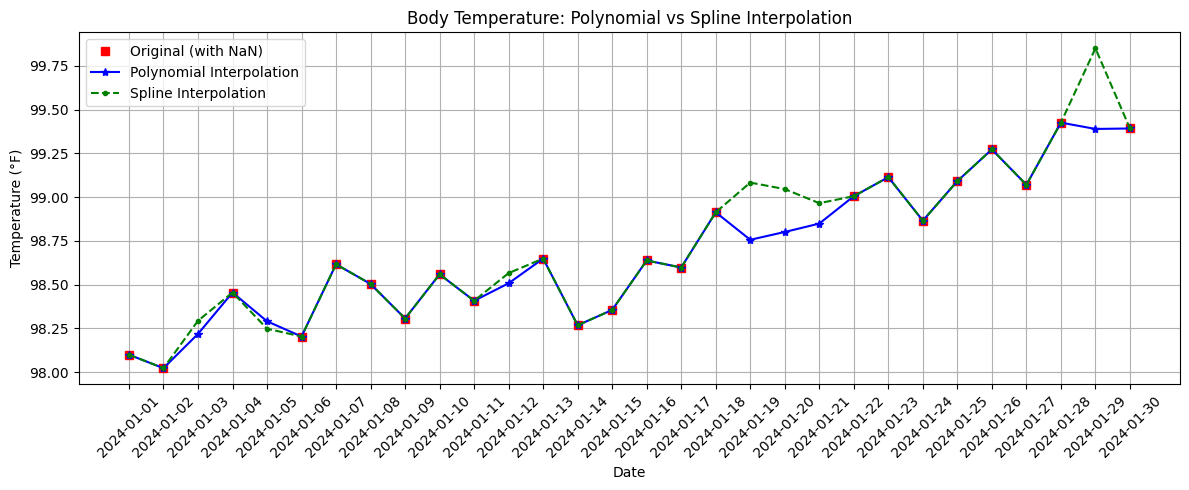

In [63]:
# step2a : Polynomial Interpolation (Degree 3)
# Drop NaNs for interpolation
df_dropna = df.dropna()
x = df_dropna.index
y = df_dropna['Body_Temperature']

# Fit polynomial
poly = np.poly1d(np.polyfit(x, y, deg=3))

# Fill missing values
df['Temp_Polynomial'] = df['Body_Temperature']
df.loc[df['Body_Temperature'].isna(), 'Temp_Polynomial'] = poly(df.loc[df['Body_Temperature'].isna()].index)


#step2b : Spline Interpolation (Cubic)
from scipy.interpolate import CubicSpline

# Use the same x and y
cs = CubicSpline(x, y)

# Fill missing values using spline
df['Temp_Spline'] = df['Body_Temperature']
df.loc[df['Body_Temperature'].isna(), 'Temp_Spline'] = cs(df.loc[df['Body_Temperature'].isna()].index)


#step3 : Plot the Original + Interpolated Values
plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Body_Temperature'], linestyle='None', marker='s', label='Original (with NaN)', color='red')
plt.plot(df['Date'], df['Temp_Polynomial'],  linestyle='-',    marker='*', label='Polynomial Interpolation', color='blue')
plt.plot(df['Date'], df['Temp_Spline'],      linestyle='--',   marker='.', label='Spline Interpolation', color='green')

plt.title("Body Temperature: Polynomial vs Spline Interpolation")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### observetaion
The polynomial and spline interpolation did a good job. 

### 5) K-Nearest Neighbors (KNN) Imputation
Replace missing values based on the values of the k-nearest data points.

Pros:
- Uses patterns from real data, making it more accurate than mean/median imputation.
- Works well when missing values are not random.

Cons:
- Computationally expensive for large datasets.
- May distort relationships if neighbors are not similar.

**When to Use?**
- Data has relationships or correlations across columns (e.g., age may relate to weight or cholesterol).
- When missing data is not missing at random (MNAR).
- When dataset is small to medium-sized with well-defined clusters.

In [64]:
# For reproducibility
np.random.seed(42)

# # Step 1: Generate synthetic patient data
# n = 60
# ages = np.random.normal(loc=50, scale=15, size=n).round(1)  # mean age 50
# weights = np.random.normal(loc=70, scale=10, size=n).round(1)  # weight in kg
# heights = np.random.normal(loc=170, scale=10, size=n).round(1)  # height in cm
# cholesterol = np.random.normal(loc=190, scale=25, size=n).round(1)  # mg/dL

# # Step 2: Introduce ~15% missing values randomly
# def introduce_missing(data, missing_rate=0.15):
#     mask = np.random.choice([True, False], size=len(data), p=[missing_rate, 1 - missing_rate])
#     data[mask] = np.nan
#     return data

# ages = introduce_missing(ages)
# weights = introduce_missing(weights)
# heights = introduce_missing(heights)
# cholesterol = introduce_missing(cholesterol)

# # Step 3: Create DataFrame
# df = pd.DataFrame({
#     'Age': ages,
#     'Weight_kg': weights,
#     'Height_cm': heights,
#     'Cholesterol_Level': cholesterol
# })
# df.to_csv('missing_patient_info_KNN.csv', index=False)


df = pd.read_csv('missing_patient_info_KNN.csv')
print("First 10 rows of dataset with missing values:")
print(df.head(10))
print("################")
print(df.info())

First 10 rows of dataset with missing values:
    Age  Weight_kg  Height_cm  Cholesterol_Level
0  57.5        NaN        NaN              205.6
1   NaN        NaN      160.9              168.6
2   NaN        NaN      184.0              163.2
3  72.8       58.0        NaN              202.1
4  46.5        NaN        NaN              184.4
5  46.5       83.6      191.9              207.9
6  73.7       69.3        NaN              201.8
7  61.5        NaN      164.3                NaN
8  43.0       73.6      171.0              168.8
9  58.1       63.5        NaN              152.1
################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                49 non-null     float64
 1   Weight_kg          48 non-null     float64
 2   Height_cm          44 non-null     float64
 3   Cholesterol_Level  54 non-null     float64
dtypes: 


 Dataset after KNN Imputation (first 10 rows):
         Age  Weight_kg   Height_cm  Cholesterol_Level
0  57.500000  70.966667  166.466667         205.600000
1  37.766667  63.666667  160.900000         168.600000
2  49.266667  62.266667  184.000000         163.200000
3  72.800000  58.000000  182.433333         202.100000
4  46.500000  71.866667  174.500000         184.400000
5  46.500000  83.600000  191.900000         207.900000
6  73.700000  69.300000  176.133333         201.800000
7  61.500000  63.966667  164.300000         189.533333
8  43.000000  73.600000  171.000000         168.800000
9  58.100000  63.500000  173.333333         152.100000


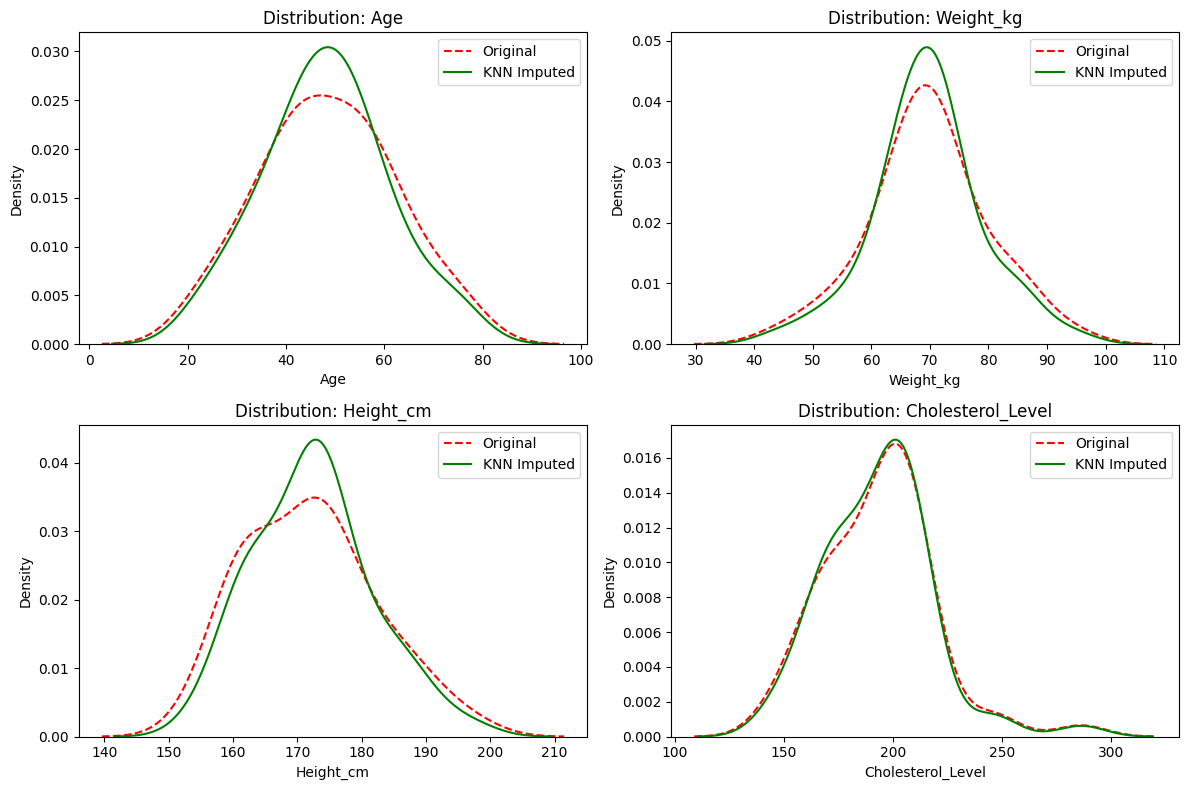

In [65]:
from sklearn.impute import KNNImputer

# Make a copy for imputation
df_knn = df.copy()

# Step 1: Initialize KNNImputer (using 3 neighbors)
imputer = KNNImputer(n_neighbors=3)

# Step 2: Fit and transform
df_knn_imputed = imputer.fit_transform(df_knn)

# Step 3: Convert back to DataFrame
df_knn_imputed = pd.DataFrame(df_knn_imputed, columns=df.columns)

# Show before and after
print("\n Dataset after KNN Imputation (first 10 rows):")
print(df_knn_imputed.head(10))

# Plot distribution before and after imputation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['Age', 'Weight_kg', 'Height_cm', 'Cholesterol_Level']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2 # row and col go from 0 to 1
    ax = axes[row, col]
    sns.kdeplot(df[feature], label='Original', ax=ax, color='red', linestyle="--")
    sns.kdeplot(df_knn_imputed[feature], label='KNN Imputed', ax=ax, color='green')
    ax.set_title(f"Distribution: {feature}")
    ax.legend()

plt.tight_layout()
plt.show()


#### obervation
**Why KNN was Beneficial Here**
- It preserved the original distribution better than mean/median, as you’ll see in the KDE plots.
- Missing values were filled contextually, not blindly. E.g., if a patient had similar age and height to another, KNN used that info to estimate weight or cholesterol.
- Works especially well in **multivariate data** (like medical records).

## 6) Iterative Imputation (Multivariate Imputation by Chained Equations - MICE)
Predicts missing values using multiple regression models iteratively. It is smarter than KNN or mean/median because:
- It builds a regression model for each feature with missing values.
- It uses other features as predictors, imputing values iteratively. This can result in more accurate and coherent imputations, especially when variables are highly correlated.

Pros:
- More sophisticated than mean/median imputation.
- Uses mutual relationships between features/columns for better accuracy (unlike KNN which only looks at distances).
- Reduces bias in the dataset.

Cons:
- Computationally expensive.
- Results depend on the chosen regression model.
- Can over-fit if too many iterations are used.

**When to Use?**
- When dataset is large, and missing values are frequent.
- When missing values depend on multiple factors (e.g., patient medical data)

Dataset after Iterative Imputation (MICE):
         Age  Weight_kg   Height_cm  Cholesterol_Level
0  57.500000  69.726500  171.983739         205.600000
1  47.785707  69.692429  160.900000         168.600000
2  47.959984  69.705280  184.000000         163.200000
3  72.800000  58.000000  171.992039         202.100000
4  46.500000  69.708719  171.976099         184.400000
5  46.500000  83.600000  191.900000         207.900000
6  73.700000  69.300000  172.005069         201.800000
7  61.500000  69.716076  164.300000         193.563633
8  43.000000  73.600000  171.000000         168.800000
9  58.100000  63.500000  171.994122         152.100000


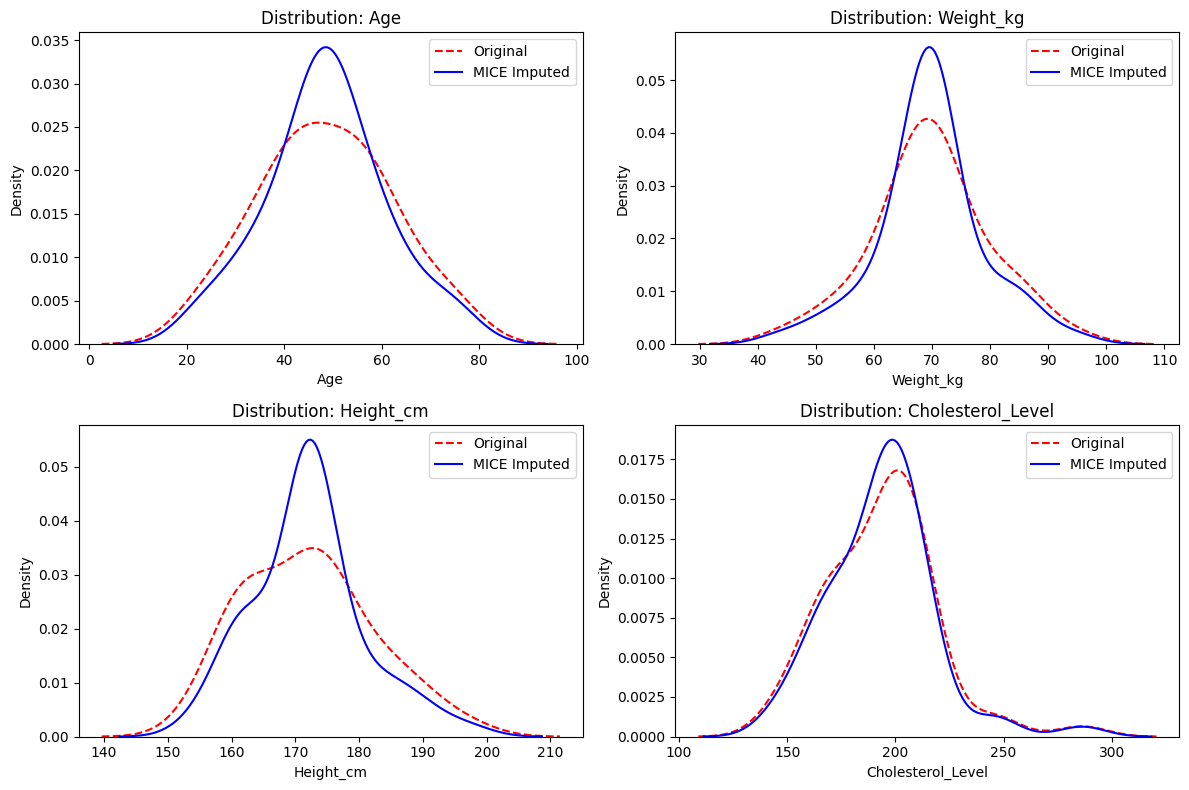

In [66]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# Make a copy
df_mice = df.copy()

# Step 1: Initialize IterativeImputer
mice_imputer = IterativeImputer(random_state=42, max_iter=10)

# Step 2: Fit and transform
df_mice_imputed = mice_imputer.fit_transform(df_mice)

# Step 3: Convert back to DataFrame
df_mice_imputed = pd.DataFrame(df_mice_imputed, columns=df.columns)

# Show results
print("Dataset after Iterative Imputation (MICE):")
print(df_mice_imputed.head(10))


# Plot distribution before and after imputation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['Age', 'Weight_kg', 'Height_cm', 'Cholesterol_Level']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    sns.kdeplot(df[feature], label='Original', ax=ax, color='red', linestyle='--')
    sns.kdeplot(df_mice_imputed[feature], label='MICE Imputed', ax=ax, color='blue')
    ax.set_title(f"Distribution: {feature}")
    ax.legend()

plt.tight_layout()
plt.show()


#### obervation
- Almost same performance as KNN(in this example)
- It preserved the original distribution better than mean/median.
- It builds a regression model for each feature with missing values
- Works especially well in **multivariate data** (like medical records).

## 7)(TODO: Did not work as desired.  OPTIONAL: Complicated process) Using Machine Learning Models to Predict Missing Values
Method: Train a machine learning model (Random Forest, XGBoost) to predict missing values based on existing ones.

Pros:
- Highly accurate when patterns exist in the data.
- Works well for both numerical and categorical missing values.

Cons:
- Computationally expensive.
- Requires a significant amount of non-missing data for training.
- Can introduce bias if the model is not well-tuned.

**When to Use?**
- When a dataset is large enough to train a predictive model.
- When missing values depend on multiple variables.


In [67]:
df = pd.read_csv('missing_synthetic_health_data_500.csv')
print(df)

     Patient_ID  Age  Gender    BMI  Blood_Pressure  Cholesterol  Glucose  \
0             1   69  Female    NaN           126.0        209.7      NaN   
1             2   32  Female  20.94             NaN        195.6    110.1   
2             3   89    Male    NaN           112.8        186.0    121.2   
3             4   78    Male  27.24           143.6        152.2    155.2   
4             5   38    Male  22.70             NaN        215.4    107.8   
..          ...  ...     ...    ...             ...          ...      ...   
495         496   34  Female    NaN           143.1        237.2    112.1   
496         497   88  Female  30.07           112.7        206.3    141.1   
497         498   62  Female  21.89           103.2        185.3     77.4   
498         499   21    Male  25.71           122.1        224.2    109.5   
499         500   53  Female  18.66            93.5        170.8     81.5   

    Smoker Diabetic Heart_Disease  
0      Yes       No           Yes  
1  

In [68]:
#check for missing values
print(df.isnull().sum())

Patient_ID         0
Age                0
Gender             0
BMI               86
Blood_Pressure    69
Cholesterol       71
Glucose           78
Smoker             0
Diabetic           0
Heart_Disease      0
dtype: int64


0


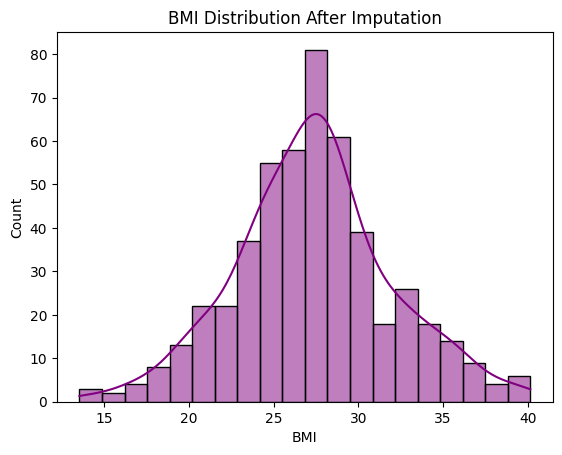

In [69]:
# Lets compute BMI first

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Drop Patient_ID (not useful for prediction)
df_model = df.drop(columns=['Patient_ID'])

# Step 2: Split the data into two sets — one with BMI, one without
df_bmi_known = df_model[df_model['BMI'].notnull()]
df_bmi_missing = df_model[df_model['BMI'].isnull()]

# Step 3: Define features and target
X = df_bmi_known.drop(columns=['BMI'])
y = df_bmi_known['BMI']

# Step 4: Preprocessing — encode categorical variables
categorical_cols = ['Gender', 'Smoker', 'Diabetic', 'Heart_Disease']
numerical_cols = ['Age', 'Blood_Pressure', 'Cholesterol', 'Glucose']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

# Step 5: Create pipeline with RandomForestRegressor
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 6: Fit the model
pipeline.fit(X, y)

# Step 7: Predict missing BMI values
X_missing = df_bmi_missing.drop(columns=['BMI'])
bmi_predicted = pipeline.predict(X_missing)

# Step 8: Fill missing BMI values in the original DataFrame
df.loc[df['BMI'].isnull(), 'BMI'] = bmi_predicted

# Step 9: Verify no more missing BMI values
print(df['BMI'].isnull().sum())  # Should print 0


sns.histplot(df['BMI'], kde=True, color='purple', bins=20)
plt.title("BMI Distribution After Imputation")
plt.xlabel("BMI")
plt.show()


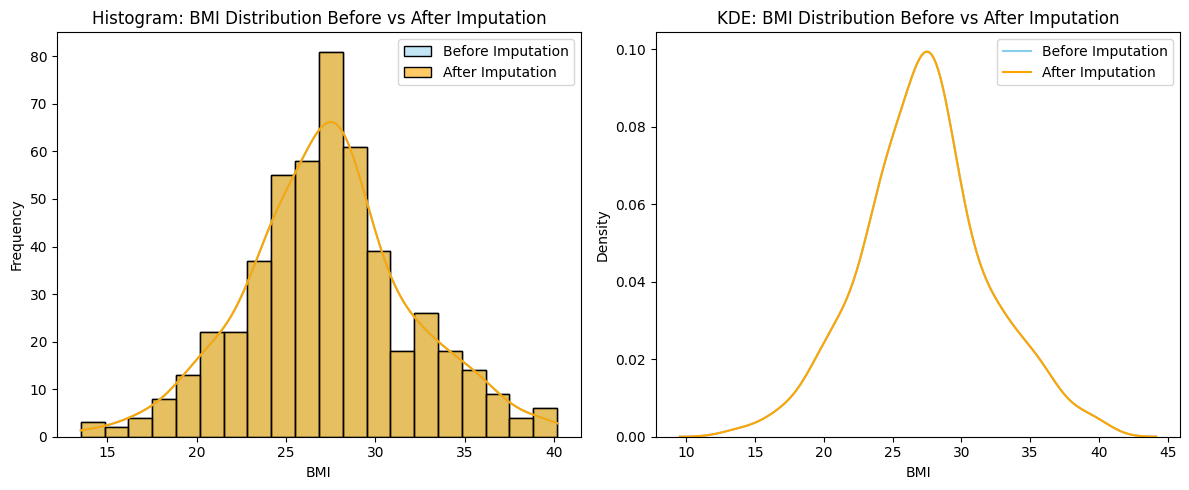

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Reload the original data to get BMI with missing values
# (Assuming you've saved the original DataFrame before imputation)
# Otherwise, simulate it again for teaching purpose
df_original = df.copy()
df_original['BMI'] = np.where(df_original.index.isin(df[df['BMI'].isnull()].index), np.nan, df_original['BMI'])

# Step 2: Create two Series for comparison
bmi_before = df_original['BMI'].dropna()   # Only non-missing values
bmi_after = df['BMI']                      # All values (after filling)

# Step 3: Plot KDE or histograms
plt.figure(figsize=(12, 5))

# Histogram comparison
plt.subplot(1, 2, 1)
sns.histplot(bmi_before, kde=True, color='skyblue', label='Before Imputation', bins=20)
sns.histplot(bmi_after, kde=True, color='orange', label='After Imputation', bins=20, alpha=0.6)
plt.title('Histogram: BMI Distribution Before vs After Imputation')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()

# KDE comparison
plt.subplot(1, 2, 2)
sns.kdeplot(bmi_before, color='skyblue', label='Before Imputation')
sns.kdeplot(bmi_after, color='orange', label='After Imputation')
plt.title('KDE: BMI Distribution Before vs After Imputation')
plt.xlabel('BMI')
plt.legend()

plt.tight_layout()
plt.show()


## Duplicates
- Remove duplicates

In [33]:
df = pd.read_csv('duplicate_cases_dataset.csv')
print(df)
print("0000000000000000000000")

# 1. Find exact duplicates:
print(df.duplicated())  # Returns True for duplicate rows (after the first occurrence)
print(df[df.duplicated()])  # View duplicate rows
print("11111111111111111111111")

# 2. Drop exact duplicates:
df = df.drop_duplicates()
print(df)
print("22222222222222222222222")

         Name            Email  Age         City
0       Alice  alice@gmail.com   25     New York
1      alice   alice@gmail.com   25     new york
2         Bob    bob@gmail.com   30  Los Angeles
3  John Smith   john@gmail.com   40      Chicago
4   Jon Smith   john@gmail.com   40      Chicago
5  John Smith   john@gmail.com   40      Chicago
6       David  david@yahoo.com   35        Miami
7       Alice  alice@gmail.com   25     New York
8         Eve  eve@outlook.com   28           NY
9         Eve  eve@outlook.com   29     New York
0000000000000000000000
0    False
1    False
2    False
3    False
4    False
5     True
6    False
7     True
8    False
9    False
dtype: bool
         Name            Email  Age      City
5  John Smith   john@gmail.com   40   Chicago
7       Alice  alice@gmail.com   25  New York
11111111111111111111111
         Name            Email  Age         City
0       Alice  alice@gmail.com   25     New York
1      alice   alice@gmail.com   25     new york
2      

In [ ]:
# 3. Check for duplicates based on subset of columns:
print(df.duplicated(subset=['Name', 'Email']))
df = df.drop_duplicates(subset=['Name', 'Email'])
print(df)